
 ## 1. Understand the problem

 The provided train_test.csv dataset is the labeled development dataset. The target variable is posted_rate, while all other relevant columns are considered potential predictors. Since posted_rate is a continuous numerical variable, this is a supervised regression problem.



 ## 2. Explore the data BEFORE splitting

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.data_ingestion  import DataIngestion
from src.visualization.eda_plots import EDAVisualizer

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

viz = EDAVisualizer()


In [2]:
# ── Load data ────────────────────────────────────────────────────
ingestor = DataIngestion(config_path="../config.yaml")
df = ingestor.load(path="../data/train-test.csv")


2026-09-05 23:05:58 | INFO     | src.data.data_ingestion | Loading data from: E:\Python projects\Spotter_Machine Learning Engineer_Assessment\data\train-test.csv
2026-09-05 23:05:58 | INFO     | src.data.data_ingestion | Loaded  shape  : (48000, 14)
2026-09-05 23:05:58 | INFO     | src.data.data_ingestion | Memory usage   : 19.23 MB
2026-09-05 23:05:58 | INFO     | src.data.data_ingestion | Target 'posted_rate' — Mean: 2,373.98


### 2.1 Basic info

In [3]:
print("=== df.shape ===")
print(df.shape)

print("\n=== df.dtypes ===")
print(df.dtypes)

print("\n=== df.info() ===")
print (df.info())

print("=== df.head ===")
df.head()


=== df.shape ===
(48000, 14)

=== df.dtypes ===
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.0912,-76.7891,38.1691,-72.7456,274.3000,Dry Van,30658.0000,2025-01-01,0.9568,2.3960,645.4100
1,TR-000002,Richmond,Philadelphia,38.0912,-76.7891,39.2232,-72.9671,280.5000,Reefer,17555.0000,2025-01-01,0.9762,2.4335,679.9700
2,TR-000003,Philadelphia,Green Bay,39.2232,-72.9671,44.3030,-87.5287,967.8000,Dry Van,31721.0000,2025-01-01,1.0097,1.8449,1802.5400
3,TR-000004,Hartford,Atlanta,39.5533,-72.1805,34.8493,-86.2894,965.4000,Dry Van,32333.0000,2025-01-01,0.9452,1.8771,1827.2800
4,TR-000005,Dallas,Nashville,31.8302,-94.3834,35.2948,-88.0892,541.9000,Reefer,35183.0000,2025-01-01,0.9848,2.5630,1380.2800


### 2.2 Missing values

In [4]:
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


=== Missing values ===
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

Total missing cells: 674


Saved → reports\figures\03_missing_values_heatmap.png


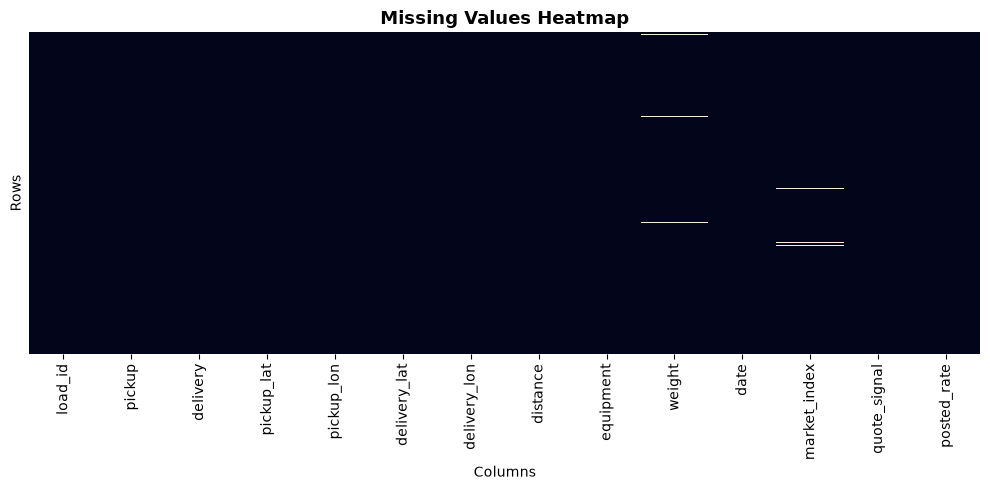

In [5]:
fig = viz.plot_missing_values_heatmap(df)

### 2.3 Duplicates

In [6]:
print("=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate load IDs:", df["load_id"].duplicated().sum())

=== Duplicates ===
Duplicate rows: 0
Duplicate load IDs: 0


### 2.4 Unique values

In [7]:
print("=== Unique values ===")
df.nunique().sort_values()


=== Unique values ===


equipment           3
delivery_lon       63
pickup_lon         63
pickup             64
delivery_lat       64
pickup_lat         64
delivery           64
date              304
distance        21204
weight          23678
market_index    32884
quote_signal    37633
posted_rate     45398
load_id         48000
dtype: int64

Saved → reports\figures\06_unique_values_barchart.png


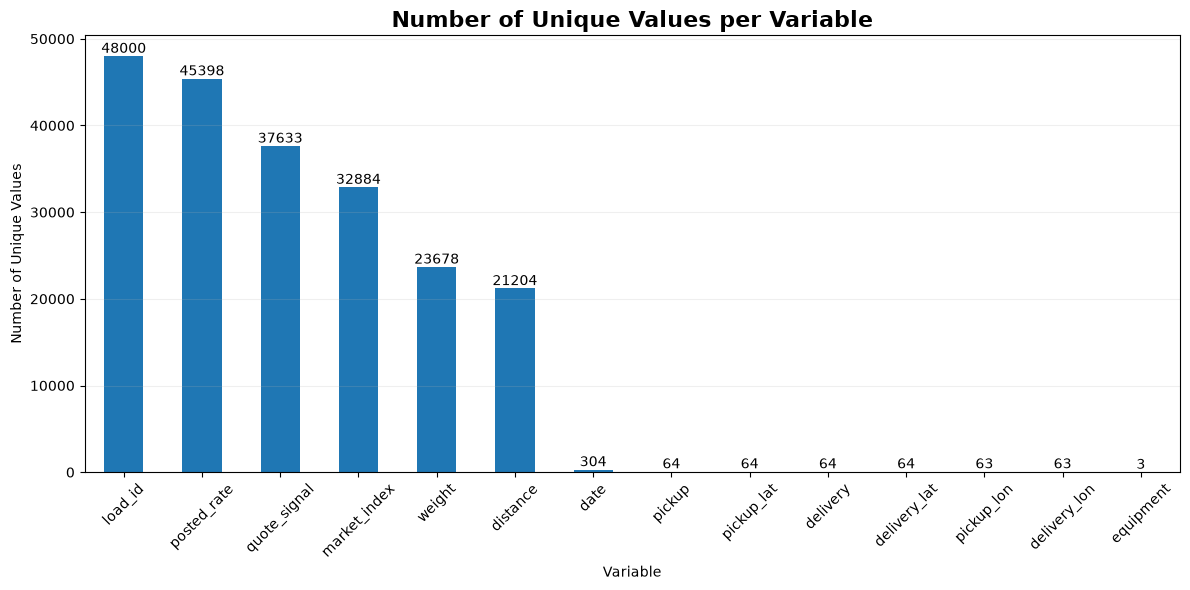

In [8]:
fig = viz.plot_unique_values(df)

### 2.5 Numerical distributions

In [9]:
print("=== df.describe() ===")
df.describe().T

=== df.describe() ===


,count,mean,std,min,25%,50%,75%,max
pickup_lat,48000.0000,35.6475,4.3153,28.3576,31.9869,35.2948,39.4110,44.3030
pickup_lon,48000.0000,-90.9290,13.4824,-121.6985,-98.4006,-88.0892,-83.2851,-69.5000
delivery_lat,48000.0000,35.6412,4.3172,28.3576,31.9869,35.2948,39.4110,44.3030
delivery_lon,48000.0000,-90.8573,13.4766,-121.6985,-98.4006,-87.5287,-83.2851,-69.5000
distance,48000.0000,1135.8567,728.5644,70.0000,550.4000,953.3000,1645.5250,3439.8000
weight,47700.0000,31028.8440,9391.4406,-47500.0000,25800.0000,31436.5000,37018.0000,47500.0000
market_index,47626.0000,1.0834,0.1681,0.6764,0.9497,1.0558,1.2196,1.4678
quote_signal,48000.0000,2.0625,0.2914,0.6923,1.8910,2.0558,2.2217,3.6103
posted_rate,48000.0000,2373.9807,1486.4932,57.2200,1251.5550,2030.7600,3330.7500,25533.0000


Saved → reports\figures\04_histogram_numerical_distributions.png


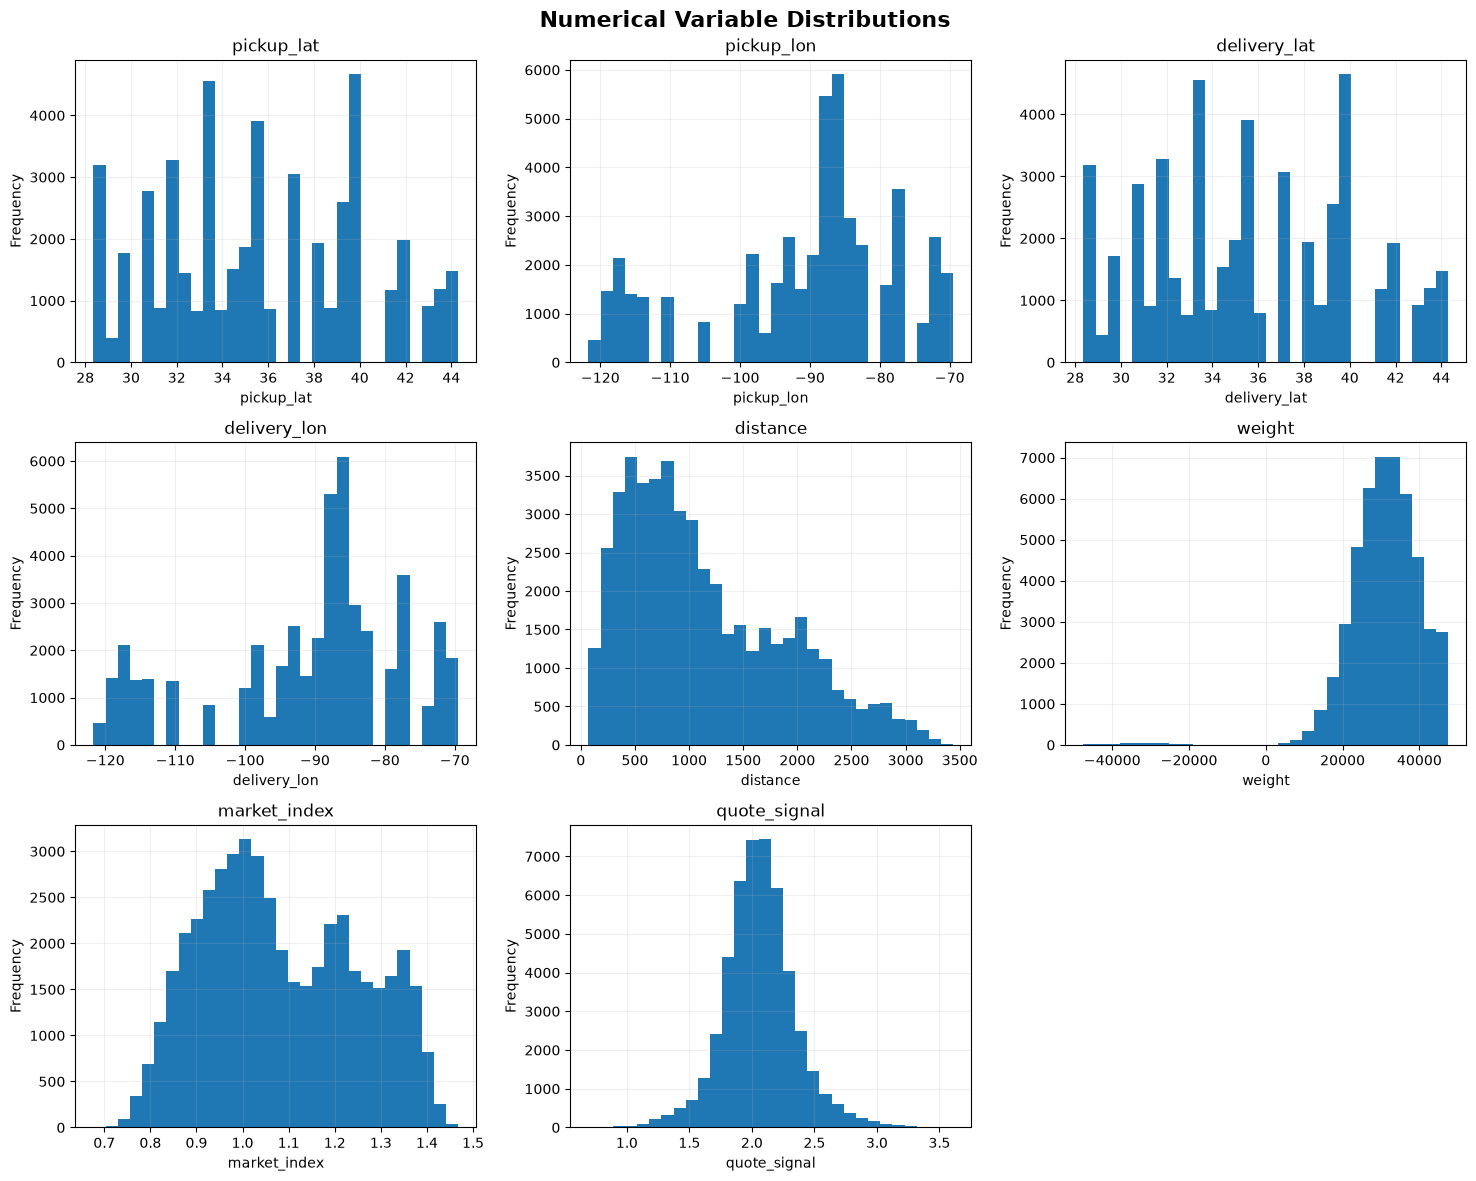

In [10]:
fig=viz.plot_numerical_distributions(df,target="posted_rate")
plt.show()

### 2.6 Categorical distributions

In [11]:
print("=== df.describe() for categorical/object columns ===")
df.describe(include="object").T

=== df.describe() for categorical/object columns ===


,count,unique,top,freq
load_id,48000,48000,TR-000001,1
pickup,48000,64,Oklahoma City,1242
delivery,48000,64,Lexington,1197
equipment,48000,3,Dry Van,27202
date,48000,304,2025-06-17,198


Saved → reports\figures\05_barplot_categorical_distributions.png


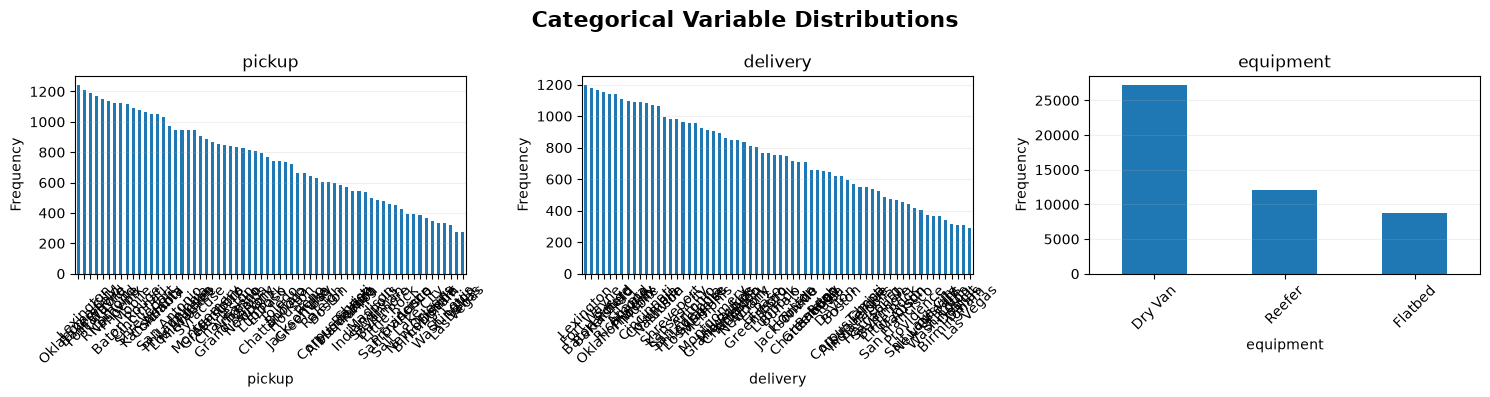

In [12]:
fig=viz.plot_categorical_distributions(df)
plt.show()

### 2.7 Outliers

In [13]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()

target = "posted_rate"

numerical_columns.remove(target)

for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

pickup_lat: 0 outliers
pickup_lon: 453 outliers
delivery_lat: 0 outliers
delivery_lon: 467 outliers
distance: 32 outliers
weight: 424 outliers
market_index: 0 outliers
quote_signal: 1956 outliers


Saved → reports\figures\07_boxplots_numerical_variables.png


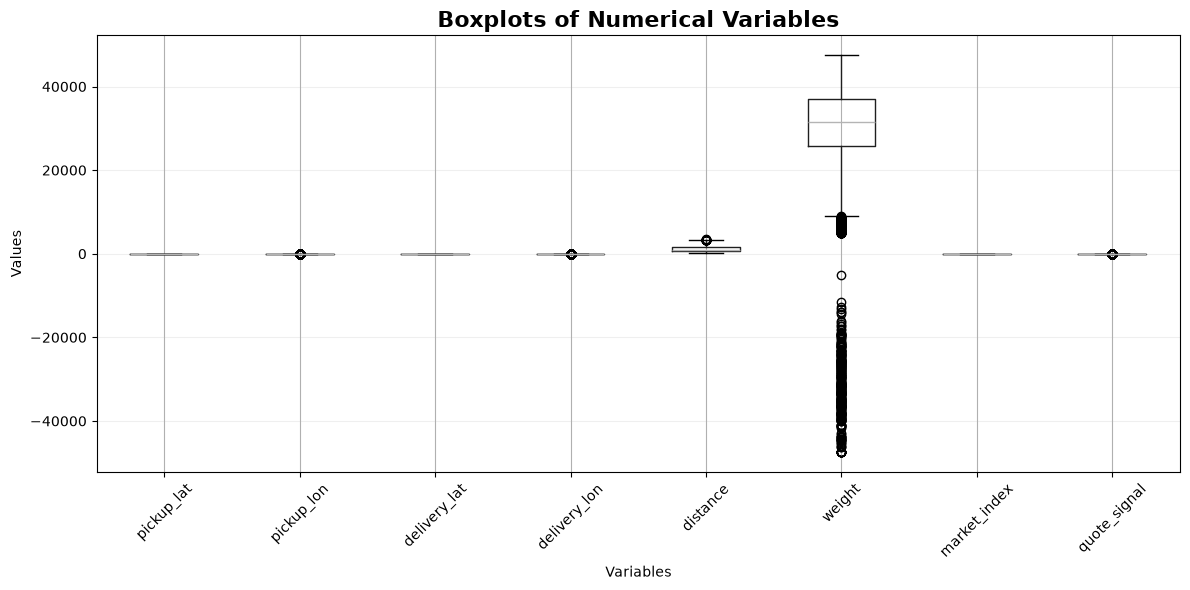

In [14]:
fig= viz.plot_boxplots(df, target="posted_rate")
plt.show()

### 2.8 Target distribution

In [15]:
print("=== Target exploration ===")
df["posted_rate"].describe()

=== Target exploration ===


count   48000.0000
mean     2373.9807
std      1486.4932
min        57.2200
25%      1251.5550
50%      2030.7600
75%      3330.7500
max     25533.0000
Name: posted_rate, dtype: float64

Saved → reports\figures\02_histogram_target_distributionposted_rate.png


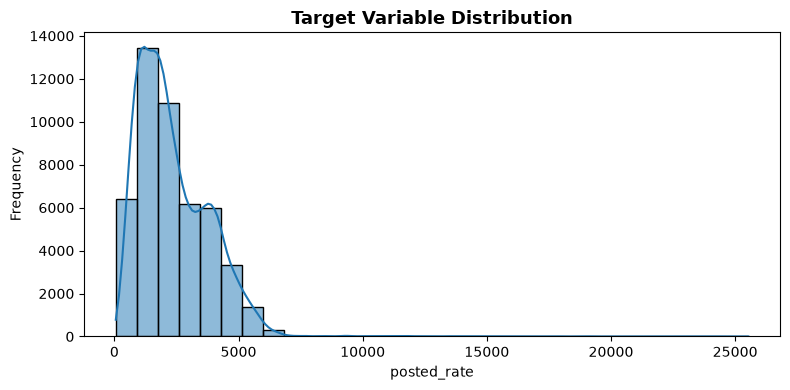

In [16]:
fig = viz.plot_target_distribution(df,"posted_rate",title="Target Variable Distribution")

### 2.9 Correlations
#### 2.9.1 Numerical features with Target


Saved → reports\figures\08_numerical_features_vs_target.png


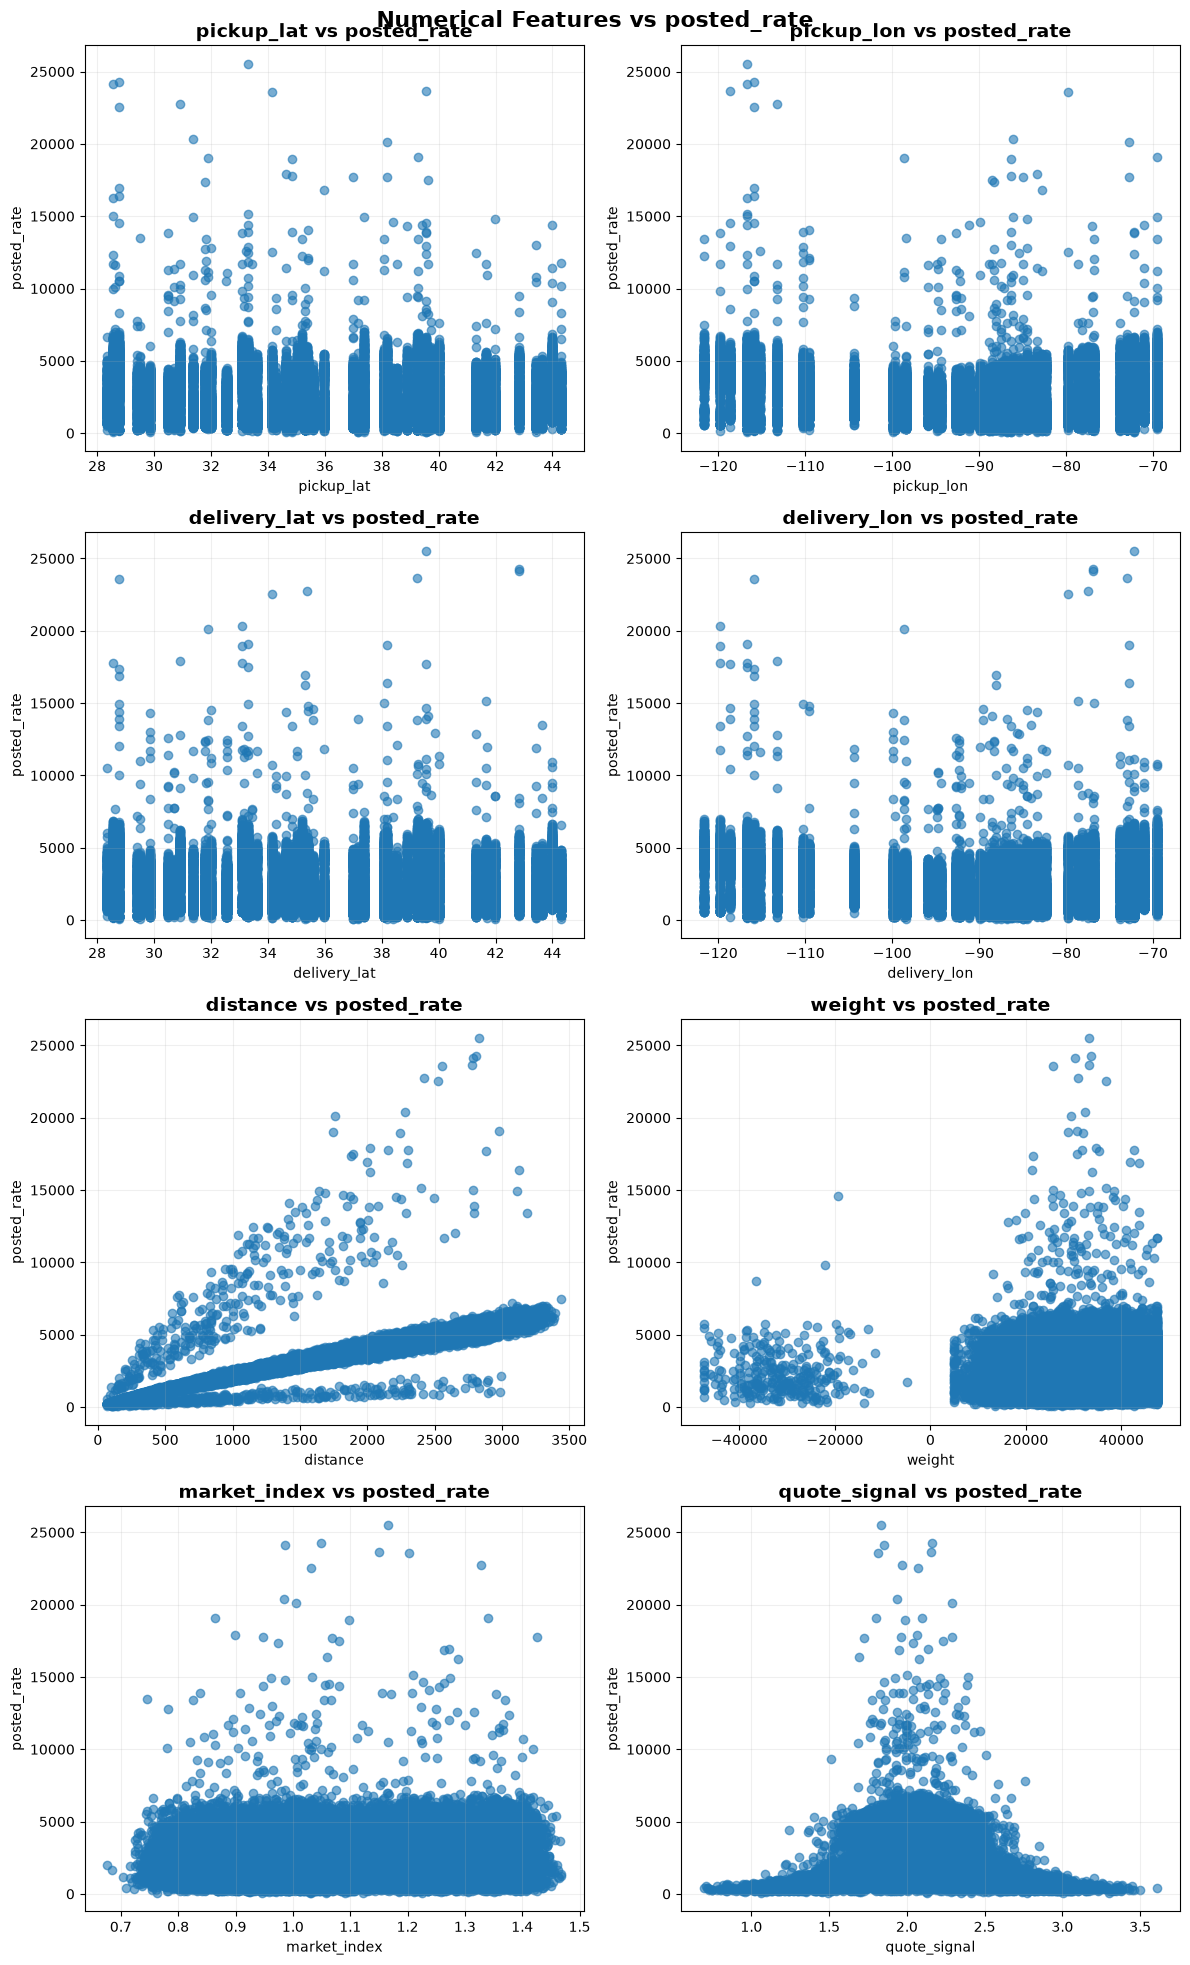

In [17]:
fig = viz.plot_numerical_features_vs_target(
    df,
    target="posted_rate"
)

plt.show()

#### 2.9.2 Categorical features with Target


Saved → reports\figures\09_categorical_features_vs_target.png


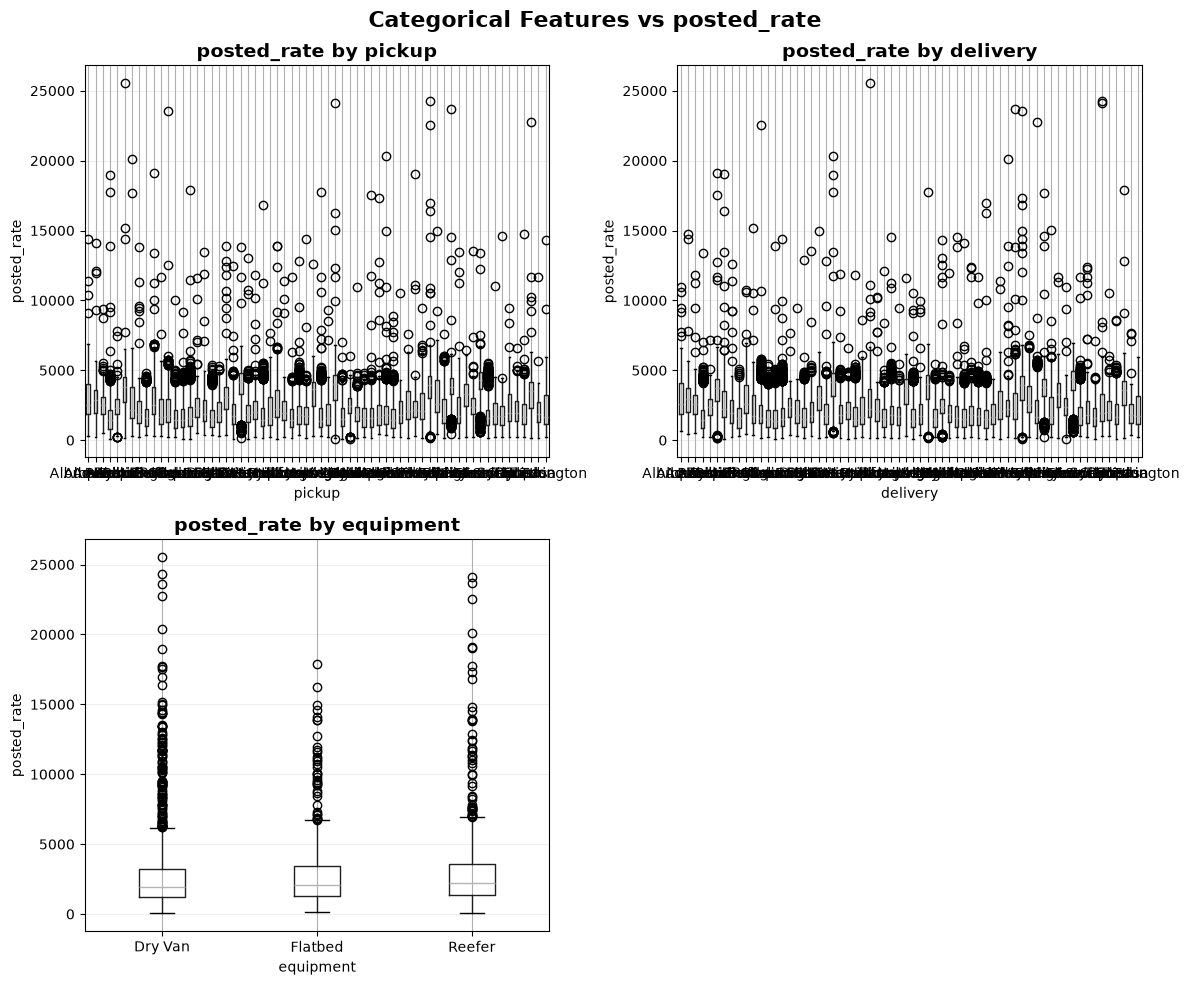

In [18]:
fig = viz.plot_categorical_features_vs_target(
    df,
    target="posted_rate"
)

plt.show()

#### 2.9.3 Numerical features with Numerical features


Saved → reports\figures\10_correlation_heatmap.png


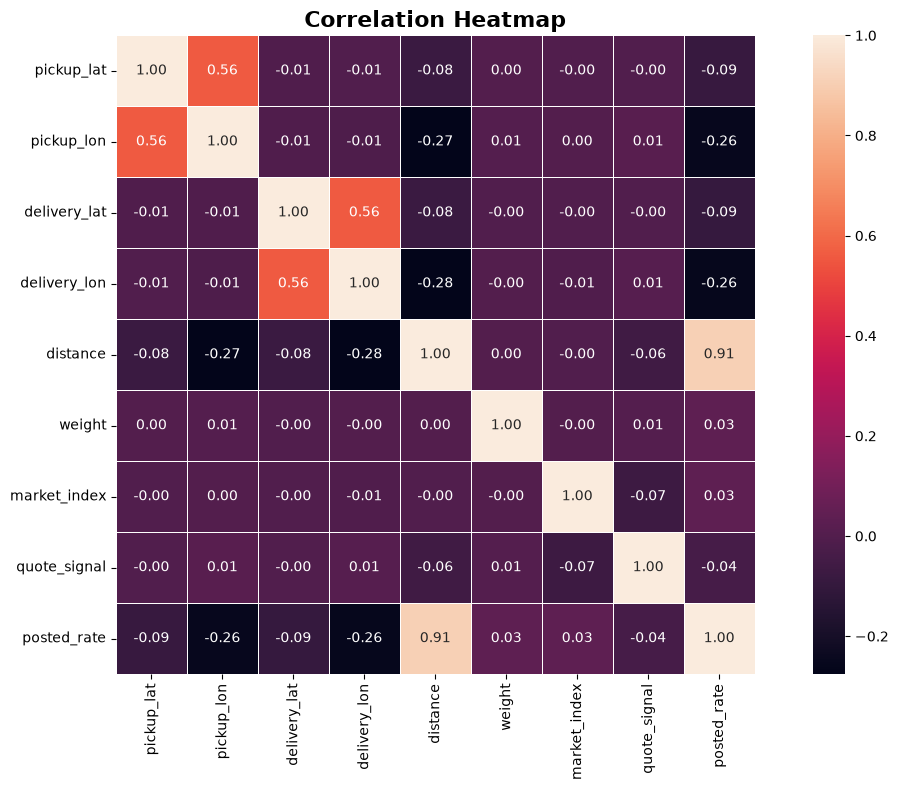

In [19]:
fig = viz.plot_correlation_heatmap(df)

plt.show()

 ### 2.10 Inspect date

In [20]:
print("=== DATE RANGE ===")

df["date"] = pd.to_datetime(df["date"])

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())
print("Missing/invalid dates:", df["date"].isna().sum())


=== DATE RANGE ===
Minimum date: 2025-01-01 00:00:00
Maximum date: 2025-10-31 00:00:00
Missing/invalid dates: 0


Saved → reports\figures\12_monthly_load_distribution.png


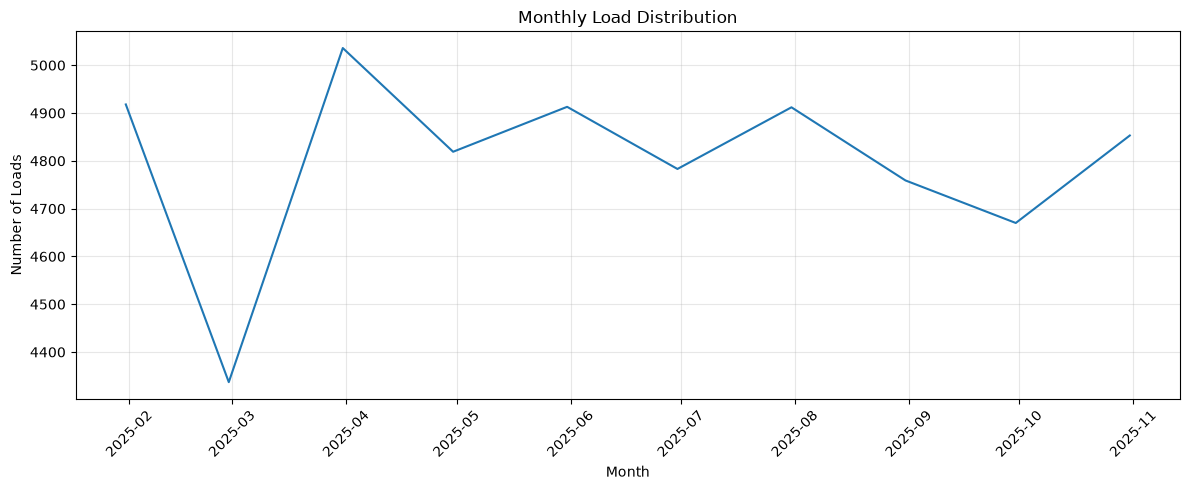

In [21]:
fig = viz.plot_monthly_load_distribution(df)
plt.show()

 ### 2.11 Inspect weight

In [22]:
print("\nNegative weights:")
print((df["weight"] < 0).sum())

print("\nZero weights:")
print((df["weight"] == 0).sum())

print("\nInfinite weights:")
print(np.isinf(df["weight"]).sum())

invalid_weight = df[
    (df["weight"] <= 0) |
    (~np.isfinite(df["weight"]))
]

print(invalid_weight[["load_id", "weight"]])


Negative weights:
292

Zero weights:
0

Infinite weights:
0
         load_id      weight
68     TR-000069 -36559.0000
204    TR-000205 -26670.0000
206    TR-000207 -20003.0000
225    TR-000226 -23981.0000
323    TR-000324         NaN
...          ...         ...
47700  TR-047701         NaN
47735  TR-047736 -43951.0000
47808  TR-047809         NaN
47850  TR-047851 -28144.0000
47868  TR-047869 -36262.0000

[592 rows x 2 columns]


 ### 2.12 Inspect coordinates 

In [23]:
coordinate_rules = {
    "pickup_lat": (-90, 90),
    "pickup_lon": (-180, 180),
    "delivery_lat": (-90, 90),
    "delivery_lon": (-180, 180),
}

for col, (lower, upper) in coordinate_rules.items():
    invalid_mask = ~df[col].between(lower, upper)
    
    invalid_count = invalid_mask.sum()

    print(f"{col}: {invalid_count} invalid values")

    if invalid_count > 0:
        print(df.loc[invalid_mask, ["load_id", col]])

pickup_lat: 0 invalid values
pickup_lon: 0 invalid values
delivery_lat: 0 invalid values
delivery_lon: 0 invalid values


Saved → reports\figures\12_coordinate_map.png


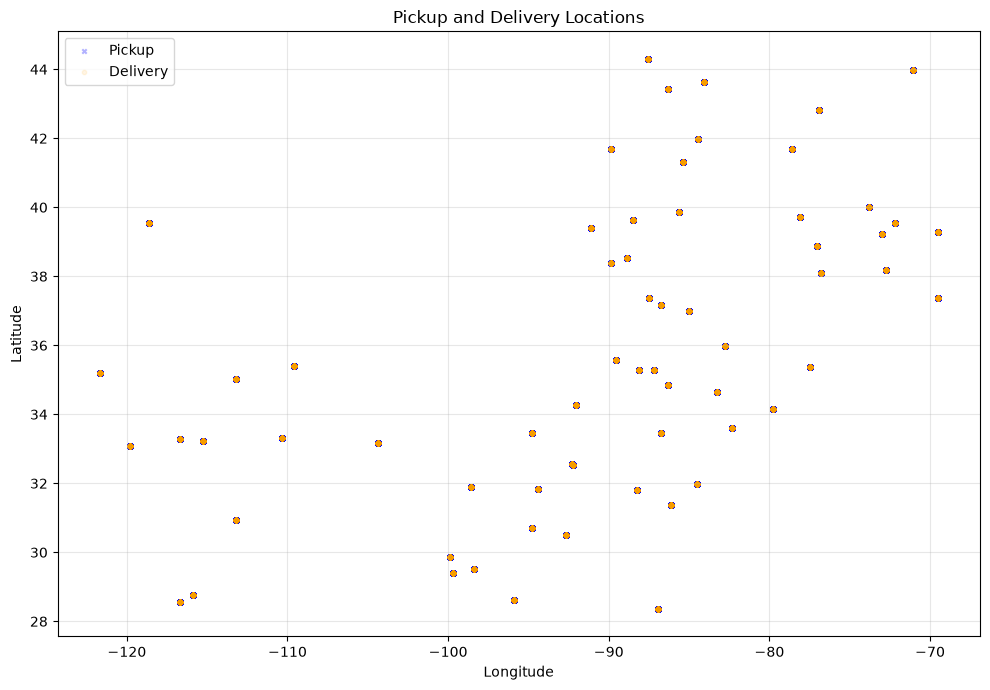

In [24]:
fig = viz.plot_coordinate_map(df)
plt.show()

 ### 2.13 Inspect pickup & delivery locations

Saved → reports\figures\15_pickup_rate_by_location.png


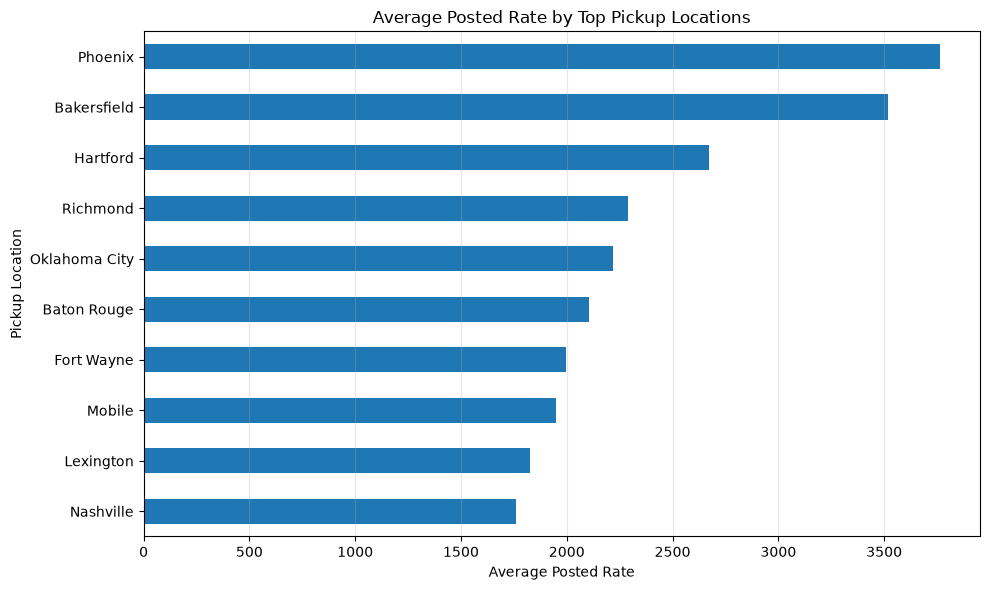

Saved → reports\figures\16_delivery_rate_by_location.png


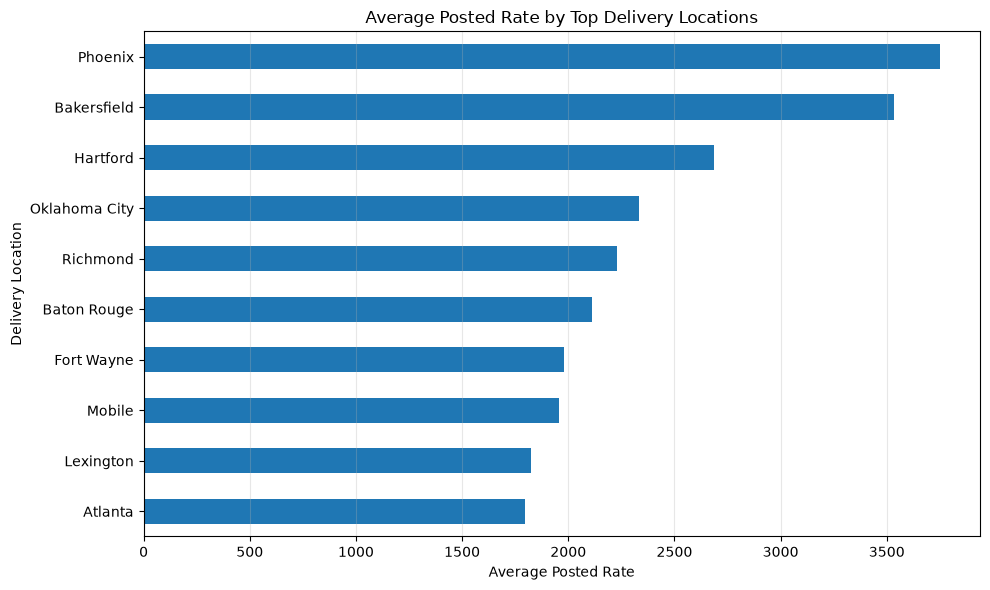

In [25]:
fig = viz.plot_pickup_rate_by_location(df)
plt.show()

fig = viz.plot_delivery_rate_by_location(df)
plt.show()

 ### 2.14 Inspect quote_signal

In [26]:
Q1 = df["quote_signal"].quantile(0.25)
Q3 = df["quote_signal"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["quote_signal"] < lower) |
    (df["quote_signal"] > upper)
].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

outliers[["quote_signal", "posted_rate"]].describe()

Q1: 1.89103
Q3: 2.221685
IQR: 0.3306549999999999
Lower bound: 1.3950475
Upper bound: 2.7176674999999997
Number of outliers: 1956


,quote_signal,posted_rate
count,1956.0000,1956.0000
mean,2.1843,669.0441
std,0.8351,398.8070
min,0.6923,63.3600
25%,1.3088,412.3750
50%,2.7410,593.5750
75%,2.8786,839.1575
max,3.6103,7773.3700


In [27]:
outliers.groupby(
    pd.qcut(outliers["quote_signal"], 10)
)["posted_rate"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
quote_signal,,,,,
"(0.691, 1.172]",196,459.4445,413.3850,63.3600,1358.9900
"(1.172, 1.268]",196,620.0154,575.8400,173.0300,4445.2300
"(1.268, 1.334]",195,700.3383,657.8200,200.5600,2526.5200
"(1.334, 1.381]",196,742.3062,679.3350,157.7600,4407.5300
"(1.381, 2.741]",195,786.5955,728.2500,200.2300,1796.0900
"(2.741, 2.785]",196,868.1218,798.8850,75.1900,7773.3700
"(2.785, 2.844]",195,759.4794,714.3100,196.3700,2383.7600
"(2.844, 2.919]",196,682.8564,611.5900,215.7000,3286.3100
"(2.919, 3.038]",195,604.8196,569.9100,76.5400,1565.6300


 ### 2.11 Dataset overview table

Saved → reports\figures\01_overview_table.png


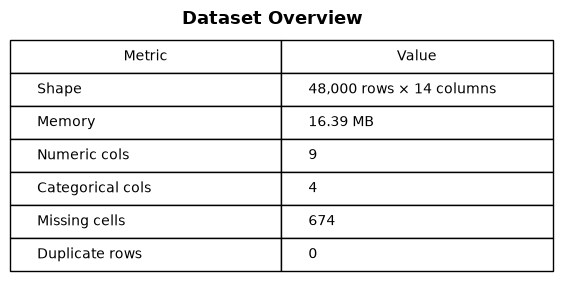

In [28]:
fig = viz.plot_overview_table(df)
plt.show()


 ### Key observations from EDA

| Finding | Observation / Decision |
|---|---|
| 2 columns have missing values: `weight`, `market_index` | Missing values need to be handled during preprocessing. |
| 0 duplicates | No duplicate rows need to be removed. |
| All `load_id` values are unique | `load_id` will be excluded from modeling. |
| 64 pickup + 64 delivery locations | These categorical variables need to be encoded. |
| 3 equipment categories | `equipment` needs categorical encoding. |
| Date range: Jan 1 – Oct 31, 2025 | I will extract useful time-based features such as month, day of week, and weekend. |
| Negative values in `weight` | These values are invalid and need to be investigated before modeling. |
| Coordinates are within valid geographic ranges | No obvious geographic outliers were found. |
| `distance` is right-skewed, max = 3,439 | The extreme values may be legitimate, so I decided to keep them. |
| Very large positive `weight` values | These need further investigation. I need more information from the dataset dictionary before deciding how to handle them. |
| `market_index` has no IQR outliers | No outlier treatment is needed based on this check. |
| `quote_signal` has 1,956 IQR outliers | After investigating them, I found that they occur in both tails and have a systematic relationship with `posted_rate`. The relationship also appears nonlinear and roughly inverted-U shaped, so I decided to keep these observations rather than remove or winsorize them. |
| Outlier treatment differs by variable | I decided not to remove all IQR outliers automatically and instead consider the meaning of each variable. |
| `posted_rate` is the target | This is a supervised regression problem. |
| `distance` has the strongest numerical relationship with the target | It is expected to be an important predictive feature. |
| `distance` ↔ `posted_rate`: r ≈ 0.91 | There is a strong positive relationship between distance and the target. |
| Temporal structure is present | I will use date-based features and chronological validation. |
| `quote_signal` and `market_index` may contain target-related information | I checked these features for possible leakage. I did not find clear evidence that they were calculated using `posted_rate` or future information, so I kept them for modeling and will evaluate them during training. |
